<a href="https://colab.research.google.com/github/SimbakNetmind/series-de-tiempo/blob/M%C3%A9todos_para_Pron%C3%B3stico_y_Anal%C3%ADtica-Avanzada/04_M%C3%A9todos_de_suavizado_Tarea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 👽 ***Tarea del Tema 1: Métodos de suavizado***

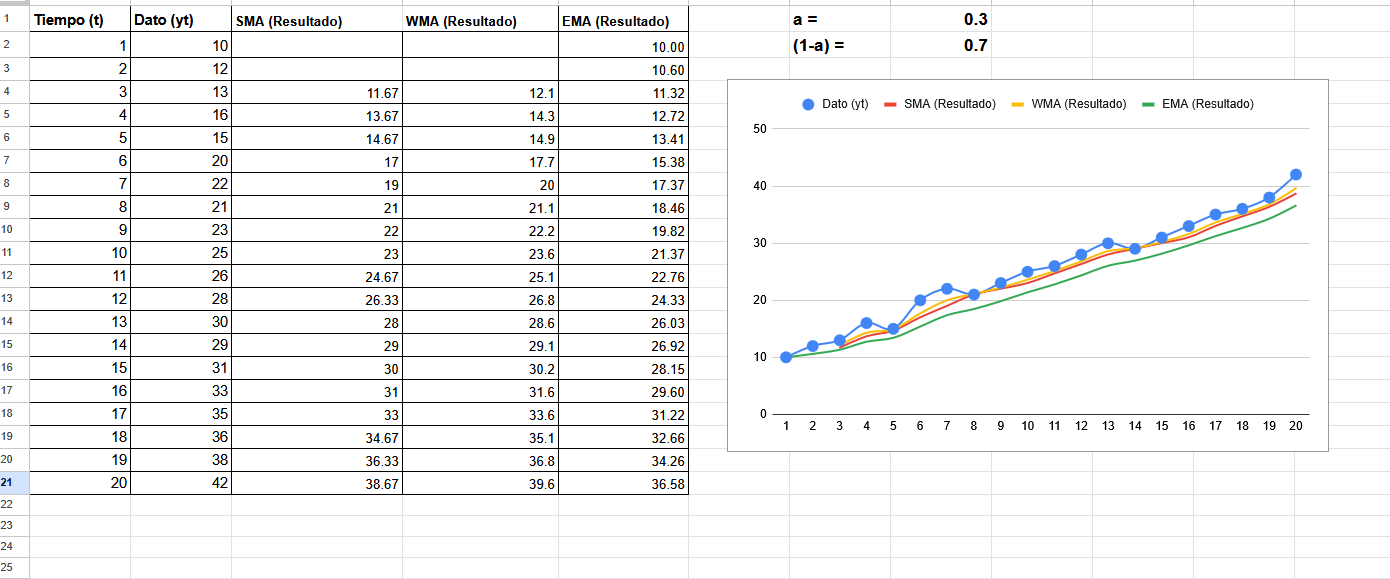

## 🎯 ***Práctica codigo (SMA,WMA y EMA)***

In [24]:
import pandas as pd
import numpy as np

# Serie de tiempo
data = [10, 12, 13, 16, 15, 20, 22, 21, 23, 25,
        26, 28, 30, 29, 31, 33, 35, 36, 38, 42]
serie = pd.Series(data)

# 1. Media Móvil Simple (SMA) - Ventana de 3
# En tu Excel, el resultado sale en la misma fila que el tercer dato
sma_forecast = serie.rolling(window=3).mean()

# 2. Media Móvil Ponderada (WMA)
weights = np.array([0.2, 0.3, 0.5])

def wma(x):
    return np.dot(x, weights)

wma_forecast = serie.rolling(window=3).apply(wma, raw=True)

# 3. Media Móvil Exponencial (EMA)
# Según tu Excel: a = 0.3
alpha_val = 0.3

# Para que coincida con Excel:
# adjust=False usa la fórmula recursiva: y(t) = (1-a)y(t-1) + ax(t)
ema_forecast = serie.ewm(alpha=alpha_val, adjust=False).mean()

# Creamos el DataFrame de comparación
df_resultados = pd.DataFrame({
    'Tiempo (t)': range(1, len(data) + 1),
    'Dato (yt)': serie,
    'SMA (Resultado)': sma_forecast,
    'WMA (Resultado)': wma_forecast,
    'EMA (Resultado)': ema_forecast
})

# Redondeamos a 2 decimales para que se vea igual que el Excel
print(df_resultados.round(2).to_string(index=False))

 Tiempo (t)  Dato (yt)  SMA (Resultado)  WMA (Resultado)  EMA (Resultado)
          1         10              NaN              NaN            10.00
          2         12              NaN              NaN            10.60
          3         13            11.67             12.1            11.32
          4         16            13.67             14.3            12.72
          5         15            14.67             14.9            13.41
          6         20            17.00             17.7            15.38
          7         22            19.00             20.0            17.37
          8         21            21.00             21.1            18.46
          9         23            22.00             22.2            19.82
         10         25            23.00             23.6            21.37
         11         26            24.67             25.1            22.76
         12         28            26.33             26.8            24.33
         13         30            28.0

---
## 📈 ***Grafica serie (SMA,WMA,EMA) vs Dato Reales***

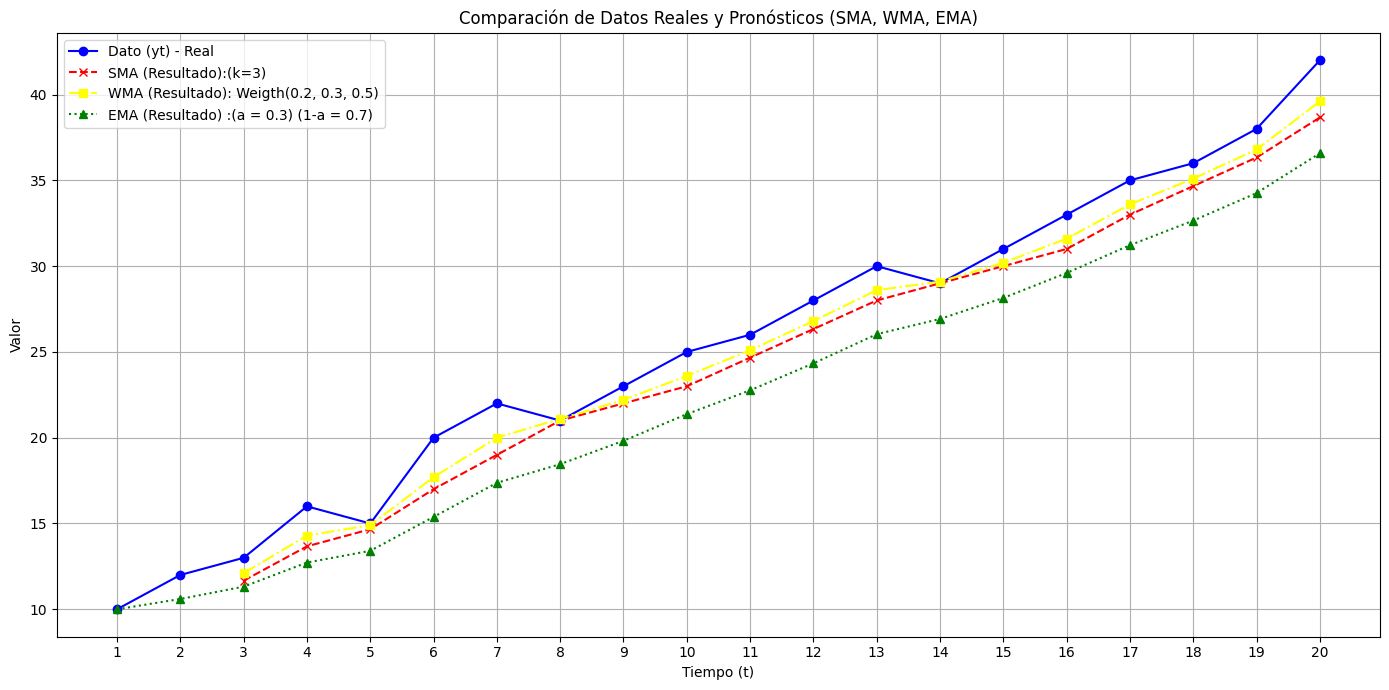

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df_resultados['Tiempo (t)'], df_resultados['Dato (yt)'], label='Dato (yt) - Real', marker='o', linestyle='-', color='blue')
plt.plot(df_resultados['Tiempo (t)'], df_resultados['SMA (Resultado)'], label='SMA (Resultado):(k=3)', marker='x', linestyle='--', color='red')
plt.plot(df_resultados['Tiempo (t)'], df_resultados['WMA (Resultado)'], label='WMA (Resultado): Weigth(0.2, 0.3, 0.5)', marker='s', linestyle='-.', color='yellow')
plt.plot(df_resultados['Tiempo (t)'], df_resultados['EMA (Resultado)'], label='EMA (Resultado) :(a = 0.3) (1-a = 0.7)', marker='^', linestyle=':', color='green')

plt.title('Comparación de Datos Reales y Pronósticos (SMA, WMA, EMA)')
plt.xlabel('Tiempo (t)')
plt.ylabel('Valor')
plt.xticks(df_resultados['Tiempo (t)']) # Set x-ticks to all integer values from 'Tiempo (t)'
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()